<a href="https://colab.research.google.com/github/fausharkgirl/GD_Terminal/blob/main/Whitehead_Assignment__Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install brian2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.1 MB/s eta 0:00:00


In [2]:
from brian2 import *

%matplotlib inline
defaultclock.dt = 0.01*ms #determining step size for differential equation solver

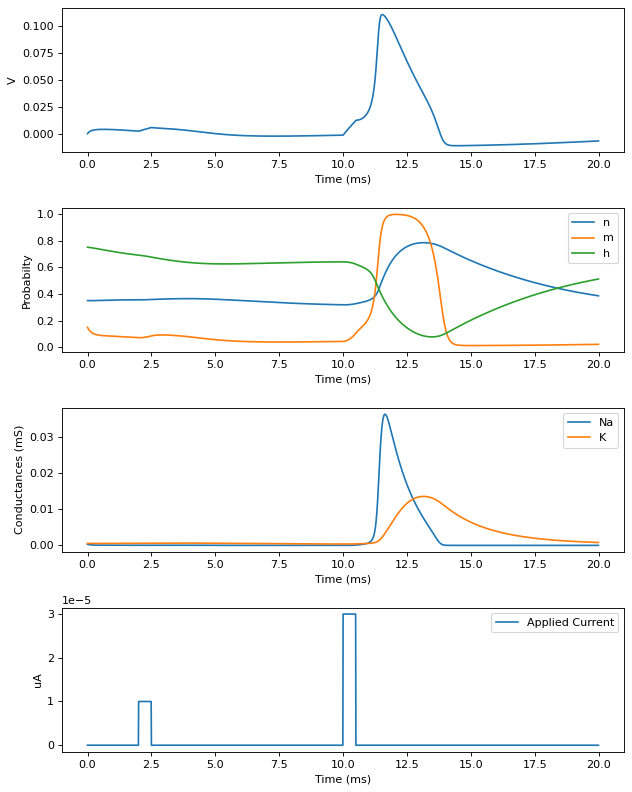

In [4]:
start_scope()
Cm = 1.0*ufarad
El = 10.6*mV
ENa = 120.0*mV
EK = -12.0*mV
gl0 = 0.3*msiemens
gNa0 = 120.0*msiemens
gK0 = 36.0*msiemens

eqs = '''
dv/dt = (I - gl * (v-El) - gNa * m**3 * h * (v-ENa) - gK * n**4 * (v-EK))/Cm : volt
I : amp (constant) # applied current

dm/dt = alpham * (1-m) - betam * m : 1
dh/dt = alphah * (1-h) - betah * h : 1
dn/dt = alphan * (1-n) - betan * n : 1

alpham = (0.1/mV) * 10*mV/exprel((-v+25*mV)/(10*mV))/ms : Hz
betam = 4 * exp(-v/(18*mV))/ms : Hz

alphah = 0.07 * exp(-v/(20*mV))/ms : Hz
betah = 1/(exp((-v+30*mV) / (10*mV)) + 1)/ms : Hz

alphan = (0.01/mV) * 10*mV/exprel((-v+10*mV)/(10*mV))/ms : Hz
betan = 0.125 * exp(-v/(80*mV))/ms : Hz

gNa : siemens
gK : siemens
gl : siemens
'''

HH = NeuronGroup(1, eqs, method='rk4')

HH.v = 0.0*mV

HH.h = 0.75
HH.m = 0.15
HH.n = 0.35

HH.gNa = gNa0
HH.gK = gK0
HH.gl = gl0

statemon = StateMonitor(HH, True, record=True)

HH.I = 0.0*uA
run(2*ms)
HH.I = 10.0*uA
run(0.5*ms)
HH.I = 0.0*uA
run(7.5*ms)
HH.I = 30.0*uA
run(0.5*ms)
HH.I = 0.0*uA
run(9.5*ms)

figure(figsize=(8, 10), dpi=80)
subplot(4,1,1)
plot(statemon.t/ms, statemon.v[0])
xlabel('Time (ms)')
ylabel('V');

subplot(4,1,2)
plot(statemon.t/ms, statemon.n[0], label='n')
plot(statemon.t/ms, statemon.m[0], label='m')
plot(statemon.t/ms, statemon.h[0], label='h')
xlabel('Time (ms)')
ylabel('Probabilty')
legend()

subplot(4,1,3)
plot(statemon.t/ms, statemon.gNa[0]*(statemon.m[0]**3)*statemon.h[0], label='Na')
plot(statemon.t/ms, statemon.gK[0]*(statemon.n[0]**4), label='K')
xlabel('Time (ms)')
ylabel('Conductances (mS)')
legend()


subplot(4,1,4)
plot(statemon.t/ms, statemon.I[0], label='Applied Current')
xlabel('Time (ms)')
ylabel('uA')
legend()
tight_layout()
show()

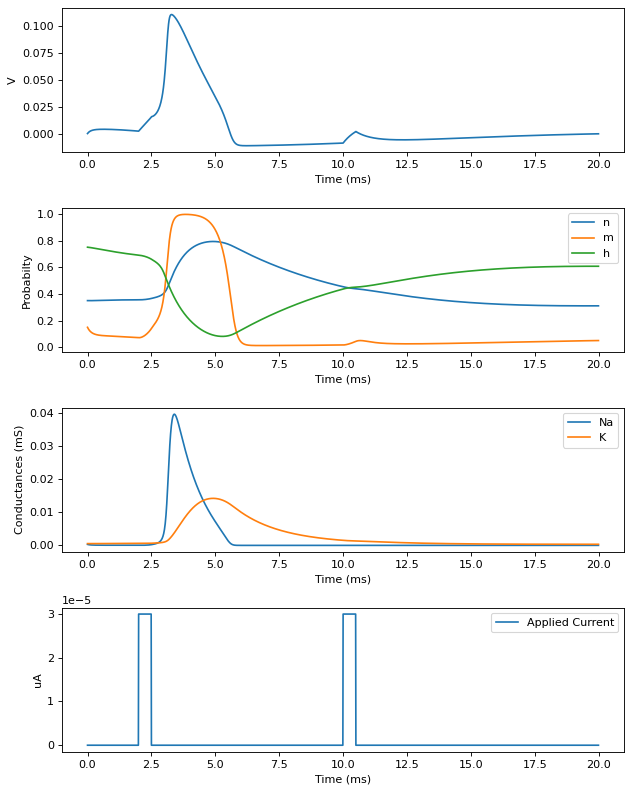

In [6]:
#b)
start_scope()
Cm = 1.0*ufarad
El = 10.6*mV
ENa = 120.0*mV
EK = -12.0*mV
gl0 = 0.3*msiemens
gNa0 = 120.0*msiemens
gK0 = 36.0*msiemens

eqs = '''
dv/dt = (I - gl * (v-El) - gNa * m**3 * h * (v-ENa) - gK * n**4 * (v-EK))/Cm : volt
I : amp (constant) # applied current

dm/dt = alpham * (1-m) - betam * m : 1
dh/dt = alphah * (1-h) - betah * h : 1
dn/dt = alphan * (1-n) - betan * n : 1

alpham = (0.1/mV) * 10*mV/exprel((-v+25*mV)/(10*mV))/ms : Hz
betam = 4 * exp(-v/(18*mV))/ms : Hz

alphah = 0.07 * exp(-v/(20*mV))/ms : Hz
betah = 1/(exp((-v+30*mV) / (10*mV)) + 1)/ms : Hz

alphan = (0.01/mV) * 10*mV/exprel((-v+10*mV)/(10*mV))/ms : Hz
betan = 0.125 * exp(-v/(80*mV))/ms : Hz

gNa : siemens
gK : siemens
gl : siemens
'''

HH = NeuronGroup(1, eqs, method='rk4')

HH.v = 0.0*mV

HH.h = 0.75
HH.m = 0.15
HH.n = 0.35

HH.gNa = gNa0
HH.gK = gK0
HH.gl = gl0

statemon = StateMonitor(HH, True, record=True)

HH.I = 0.0*uA
run(2*ms)

#Firstpulse increased from 10 to 30
#First action potential between 3 and 6 ms.  2nd pulse around 10 ms is not an action potential.  The Na Activation (h) is recovering and K remains elevated, but declining.  This makes the membrane less excitable during 2nd stimulus. aka Refractory period

HH.I = 30.0*uA
run(0.5*ms)
HH.I = 0.0*uA
run(7.5*ms)
HH.I = 30.0*uA
run(0.5*ms)
HH.I = 0.0*uA
run(9.5*ms)

figure(figsize=(8, 10), dpi=80)
subplot(4,1,1)
plot(statemon.t/ms, statemon.v[0])
xlabel('Time (ms)')
ylabel('V');

subplot(4,1,2)
plot(statemon.t/ms, statemon.n[0], label='n')
plot(statemon.t/ms, statemon.m[0], label='m')
plot(statemon.t/ms, statemon.h[0], label='h')
xlabel('Time (ms)')
ylabel('Probabilty')
legend()

subplot(4,1,3)
plot(statemon.t/ms, statemon.gNa[0]*(statemon.m[0]**3)*statemon.h[0], label='Na')
plot(statemon.t/ms, statemon.gK[0]*(statemon.n[0]**4), label='K')
xlabel('Time (ms)')
ylabel('Conductances (mS)')
legend()


subplot(4,1,4)
plot(statemon.t/ms, statemon.I[0], label='Applied Current')
xlabel('Time (ms)')
ylabel('uA')
legend()
tight_layout()
show()

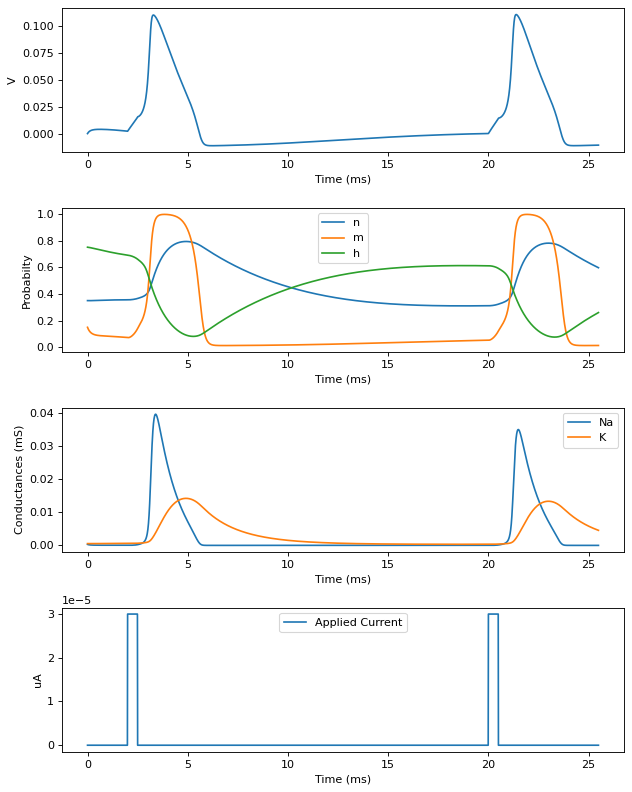

In [7]:
#c)
start_scope()
Cm = 1.0*ufarad
El = 10.6*mV
ENa = 120.0*mV
EK = -12.0*mV
gl0 = 0.3*msiemens
gNa0 = 120.0*msiemens
gK0 = 36.0*msiemens

eqs = '''
dv/dt = (I - gl * (v-El) - gNa * m**3 * h * (v-ENa) - gK * n**4 * (v-EK))/Cm : volt
I : amp (constant) # applied current

dm/dt = alpham * (1-m) - betam * m : 1
dh/dt = alphah * (1-h) - betah * h : 1
dn/dt = alphan * (1-n) - betan * n : 1

alpham = (0.1/mV) * 10*mV/exprel((-v+25*mV)/(10*mV))/ms : Hz
betam = 4 * exp(-v/(18*mV))/ms : Hz

alphah = 0.07 * exp(-v/(20*mV))/ms : Hz
betah = 1/(exp((-v+30*mV) / (10*mV)) + 1)/ms : Hz

alphan = (0.01/mV) * 10*mV/exprel((-v+10*mV)/(10*mV))/ms : Hz
betan = 0.125 * exp(-v/(80*mV))/ms : Hz

gNa : siemens
gK : siemens
gl : siemens
'''

HH = NeuronGroup(1, eqs, method='rk4')

HH.v = 0.0*mV

HH.h = 0.75
HH.m = 0.15
HH.n = 0.35

HH.gNa = gNa0
HH.gK = gK0
HH.gl = gl0

statemon = StateMonitor(HH, True, record=True)

HH.I = 0.0*uA
run(2*ms)

#Firstpulse increased from 10 to 30
#produces the first action potential
HH.I = 30.0*uA
run(0.5*ms)
HH.I = 0.0*uA
run(7.5*ms)

#Setting second pulse amplitude to zero
HH.I = 0.0*uA
run(0.5*ms)
HH.I = 0.0*uA
run(9.5*ms)

# Adding a new pulse is later, after the neuron has had time to recover
HH.I = 30.0*uA
run(0.5*ms)
HH.I = 0.0*uA
run(5.0*ms)

figure(figsize=(8, 10), dpi=80)
subplot(4,1,1)
plot(statemon.t/ms, statemon.v[0])
xlabel('Time (ms)')
ylabel('V');

subplot(4,1,2)
plot(statemon.t/ms, statemon.n[0], label='n')
plot(statemon.t/ms, statemon.m[0], label='m')
plot(statemon.t/ms, statemon.h[0], label='h')
xlabel('Time (ms)')
ylabel('Probabilty')
legend()

subplot(4,1,3)
plot(statemon.t/ms, statemon.gNa[0]*(statemon.m[0]**3)*statemon.h[0], label='Na')
plot(statemon.t/ms, statemon.gK[0]*(statemon.n[0]**4), label='K')
xlabel('Time (ms)')
ylabel('Conductances (mS)')
legend()


subplot(4,1,4)
plot(statemon.t/ms, statemon.I[0], label='Applied Current')
xlabel('Time (ms)')
ylabel('uA')
legend()
tight_layout()
show()

WARNING    neurongroup_1's variable 'n' has NaN, very large values, or encountered an error in numerical integration. This is usually a sign that an unstable or invalid integration method was chosen. [brian2.groups.group.invalid_values]
WARNING    neurongroup_1's variable 'h' has NaN, very large values, or encountered an error in numerical integration. This is usually a sign that an unstable or invalid integration method was chosen. [brian2.groups.group.invalid_values]
WARNING    neurongroup_1's variable 'm' has NaN, very large values, or encountered an error in numerical integration. This is usually a sign that an unstable or invalid integration method was chosen. [brian2.groups.group.invalid_values]
WARNING    neurongroup_1's variable 'v' has NaN, very large values, or encountered an error in numerical integration. This is usually a sign that an unstable or invalid integration method was chosen. [brian2.groups.group.invalid_values]


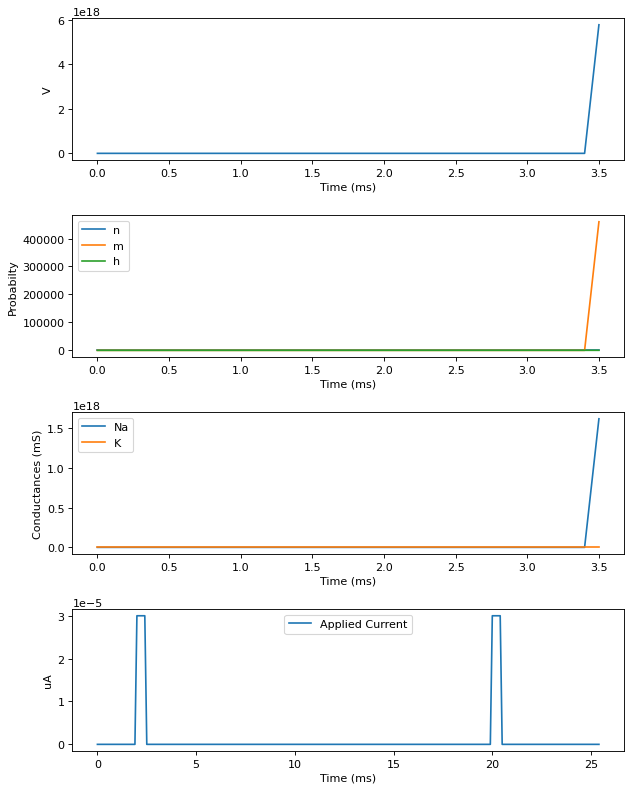

In [8]:
#d)
%matplotlib inline
defaultclock.dt = 0.1*ms #determining step size for differential equation solver
start_scope()
Cm = 1.0*ufarad
El = 10.6*mV
ENa = 120.0*mV
EK = -12.0*mV
gl0 = 0.3*msiemens
gNa0 = 120.0*msiemens
gK0 = 36.0*msiemens

eqs = '''
dv/dt = (I - gl * (v-El) - gNa * m**3 * h * (v-ENa) - gK * n**4 * (v-EK))/Cm : volt
I : amp (constant) # applied current

dm/dt = alpham * (1-m) - betam * m : 1
dh/dt = alphah * (1-h) - betah * h : 1
dn/dt = alphan * (1-n) - betan * n : 1

alpham = (0.1/mV) * 10*mV/exprel((-v+25*mV)/(10*mV))/ms : Hz
betam = 4 * exp(-v/(18*mV))/ms : Hz

alphah = 0.07 * exp(-v/(20*mV))/ms : Hz
betah = 1/(exp((-v+30*mV) / (10*mV)) + 1)/ms : Hz

alphan = (0.01/mV) * 10*mV/exprel((-v+10*mV)/(10*mV))/ms : Hz
betan = 0.125 * exp(-v/(80*mV))/ms : Hz

gNa : siemens
gK : siemens
gl : siemens
'''

HH = NeuronGroup(1, eqs, method='rk4')

HH.v = 0.0*mV

HH.h = 0.75
HH.m = 0.15
HH.n = 0.35

HH.gNa = gNa0
HH.gK = gK0
HH.gl = gl0

statemon = StateMonitor(HH, True, record=True)

HH.I = 0.0*uA
run(2*ms)

#Firstpulse increased from 10 to 30
#produces the first action potential
HH.I = 30.0*uA
run(0.5*ms)
HH.I = 0.0*uA
run(7.5*ms)

#Setting second pulse amplitude to zero
HH.I = 0.0*uA
run(0.5*ms)
HH.I = 0.0*uA
run(9.5*ms)

# Adding a new pulse is later, after the neuron has had time to recover
HH.I = 30.0*uA
run(0.5*ms)
HH.I = 0.0*uA
run(5.0*ms)

figure(figsize=(8, 10), dpi=80)
subplot(4,1,1)
plot(statemon.t/ms, statemon.v[0])
xlabel('Time (ms)')
ylabel('V');

subplot(4,1,2)
plot(statemon.t/ms, statemon.n[0], label='n')
plot(statemon.t/ms, statemon.m[0], label='m')
plot(statemon.t/ms, statemon.h[0], label='h')
xlabel('Time (ms)')
ylabel('Probabilty')
legend()

subplot(4,1,3)
plot(statemon.t/ms, statemon.gNa[0]*(statemon.m[0]**3)*statemon.h[0], label='Na')
plot(statemon.t/ms, statemon.gK[0]*(statemon.n[0]**4), label='K')
xlabel('Time (ms)')
ylabel('Conductances (mS)')
legend()


subplot(4,1,4)
plot(statemon.t/ms, statemon.I[0], label='Applied Current')
xlabel('Time (ms)')
ylabel('uA')
legend()
tight_layout()
show()

In [ ]:
#The integration time in d) was increased from 0.01 to 0.1 ms.  The larger time step reduced numerical accuracy becuase making it unstable which is why the error was presented becuase the action potential can not be calculated correctly.

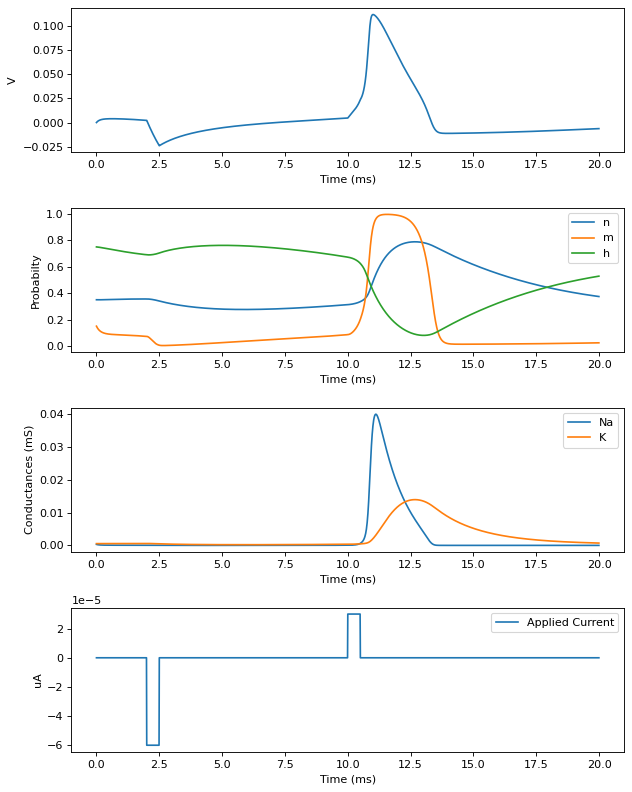

In [9]:
#e)
%matplotlib inline
defaultclock.dt = 0.01*ms # changed back determining step size for differential equation solver
start_scope()
Cm = 1.0*ufarad
El = 10.6*mV
ENa = 120.0*mV
EK = -12.0*mV
gl0 = 0.3*msiemens
gNa0 = 120.0*msiemens
gK0 = 36.0*msiemens

eqs = '''
dv/dt = (I - gl * (v-El) - gNa * m**3 * h * (v-ENa) - gK * n**4 * (v-EK))/Cm : volt
I : amp (constant) # applied current

dm/dt = alpham * (1-m) - betam * m : 1
dh/dt = alphah * (1-h) - betah * h : 1
dn/dt = alphan * (1-n) - betan * n : 1

alpham = (0.1/mV) * 10*mV/exprel((-v+25*mV)/(10*mV))/ms : Hz
betam = 4 * exp(-v/(18*mV))/ms : Hz

alphah = 0.07 * exp(-v/(20*mV))/ms : Hz
betah = 1/(exp((-v+30*mV) / (10*mV)) + 1)/ms : Hz

alphan = (0.01/mV) * 10*mV/exprel((-v+10*mV)/(10*mV))/ms : Hz
betan = 0.125 * exp(-v/(80*mV))/ms : Hz

gNa : siemens
gK : siemens
gl : siemens
'''

HH = NeuronGroup(1, eqs, method='rk4')

HH.v = 0.0*mV

HH.h = 0.75
HH.m = 0.15
HH.n = 0.35

HH.gNa = gNa0
HH.gK = gK0
HH.gl = gl0

statemon = StateMonitor(HH, True, record=True)

HH.I = 0.0*uA
run(2*ms)

#Applying negative current
HH.I = -60.0*uA
run(0.5*ms)

#remove negative current and rebound action potential should occur
HH.I = 0.0*uA
run(7.5*ms)

#returning to original 30
HH.I = 30.0*uA
run(0.5*ms)
HH.I = 0.0*uA
run(9.5*ms)

#removed new pulse


figure(figsize=(8, 10), dpi=80)
subplot(4,1,1)
plot(statemon.t/ms, statemon.v[0])
xlabel('Time (ms)')
ylabel('V');

subplot(4,1,2)
plot(statemon.t/ms, statemon.n[0], label='n')
plot(statemon.t/ms, statemon.m[0], label='m')
plot(statemon.t/ms, statemon.h[0], label='h')
xlabel('Time (ms)')
ylabel('Probabilty')
legend()

subplot(4,1,3)
plot(statemon.t/ms, statemon.gNa[0]*(statemon.m[0]**3)*statemon.h[0], label='Na')
plot(statemon.t/ms, statemon.gK[0]*(statemon.n[0]**4), label='K')
xlabel('Time (ms)')
ylabel('Conductances (mS)')
legend()


subplot(4,1,4)
plot(statemon.t/ms, statemon.I[0], label='Applied Current')
xlabel('Time (ms)')
ylabel('uA')
legend()
tight_layout()
show()

In [ ]:
#negative current applied to hyperpolarize the nueron then removed.
#the membrane recovered and produced an action potential around 10 ms as the post-hyperpolarization rebound spike